# 9. Stack Anidado — ¿el veredicto sobre la red fue del modelo o del método?

`5_red_neuronal.ipynb` concluyó que la red no aportaba nada: la búsqueda de pesos le asignó
**exactamente cero** y el barrido bajaba desde el primer punto. Pero esa búsqueda tenía una forma
concreta — un **promedio convexo**, con pesos no negativos que suman 1 — y esa forma impone una
restricción que en su momento no examinamos.

> Una combinación convexa sólo puede **promediar**. Puede decidir cuánto pesa cada modelo, pero no
> puede usar uno para **restar**. Si un modelo es útil no porque acierte sino porque sus errores
> señalan dónde se equivocan los demás, un promedio de pesos positivos no tiene forma de expresarlo:
> lo mejor que puede hacer es ignorarlo, y eso es exactamente lo que hizo.

Un **meta-modelo ajustado** —una regresión logística sobre los rangos de cada miembro— no tiene esa
restricción: sus coeficientes tienen signo. Un miembro puede entrar con peso negativo, como corrector.

Hay una segunda razón para preferirlo, que sale del notebook 7. Ahí diagnosticamos que la ganancia de
nuestro ensamble estaba **sesgada por selección**: los pesos se eligieron maximizando el mismo OOF con
el que después se midió la mejora. Un meta-modelo **anidado** resuelve ese problema de raíz: para cada
uno de los cinco folds, los coeficientes se ajustan sobre los otros cuatro y se puntúa el que quedó
afuera. Ningún peso ve la fila que califica.

**La pregunta de este notebook:** ¿el veredicto del notebook 5 era una propiedad de la red, o del
método con el que la evaluamos?

> **Tiempo de ejecución: ~5 minutos.** No entrena modelos; sólo combina los OOF ya guardados.

**Métrica:** ROC AUC · **Dataset:** Playground Series S6E8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata, norm
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED, N_FOLDS = 42, 5

## 1. Carga de las Predicciones Out-of-Fold

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")   # sin ordenar ni reindexar: el OOF se alinea por posicion
y = train["addicted_label"].values
NTR, NTE = len(train), len(test)

MIEMBROS = {
    "xgb_base":   ("3_xgboost_oof.npy",        "3_xgboost_test.npy"),
    "lgbm":       ("4_lightgbm_oof.npy",       "4_lightgbm_test.npy"),
    "red":        ("5_red_neuronal_oof.npy",   "5_red_neuronal_test.npy"),
    "xgb_optuna": ("6_xgboost_optuna_oof.npy", "6_xgboost_optuna_test.npy"),
}
oof  = {k: np.load(f"../models/{fo}") for k, (fo, _) in MIEMBROS.items()}
tst  = {k: np.load(f"../models/{ft}") for k, (_, ft) in MIEMBROS.items()}

for k in MIEMBROS:
    assert oof[k].shape == (NTR,), f"{k}: OOF desalineado"
    assert tst[k].shape == (NTE,), f"{k}: test desalineado"

FOLDS = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(np.zeros(NTR), y))

print(f"train {NTR:,} | test {NTE:,} | miembros {len(MIEMBROS)}\n")
for k in MIEMBROS:
    print(f"  {k:12s} AUC out-of-fold = {roc_auc_score(y, oof[k]):.6f}")

train 691,369 | test 296,302 | miembros 4

  xgb_base     AUC out-of-fold = 0.964776
  lgbm         AUC out-of-fold = 0.964219
  red          AUC out-of-fold = 0.940917
  xgb_optuna   AUC out-of-fold = 0.965073


## 2. Meta-features: rank-gauss

Los miembros llegan en escalas distintas: los GBM dan probabilidades concentradas cerca de 0 y 1, la
red tiene otra calibración. Para que el meta-modelo los compare de igual a igual se los pasa a
**rango** y después por la **inversa de la normal**. El ranking los vuelve conmensurables, y la cola
gaussiana recupera resolución en los extremos, donde el rango plano la pierde.

Como la métrica es AUC —que sólo mira el orden— nada de esto altera el score de un miembro individual.

In [3]:
R     = lambda v: (rankdata(v, method="average") - 0.5) / len(v)
gauss = lambda v: norm.ppf(np.clip(R(v), 1e-7, 1 - 1e-7))

nombres = list(MIEMBROS)
G  = np.column_stack([gauss(oof[k]) for k in nombres])
Gt = np.column_stack([gauss(tst[k]) for k in nombres])

print(f"Matriz de meta-features: {G.shape}")
print(f"  rango de los valores: [{G.min():.2f}, {G.max():.2f}]")
print(f"  AUC de un miembro antes y despues de la transformacion: "
      f"{roc_auc_score(y, oof['xgb_optuna']):.6f} -> "
      f"{roc_auc_score(y, gauss(oof['xgb_optuna'])):.6f}  (identico: solo cambia la escala)")

Matriz de meta-features: (691369, 4)
  rango de los valores: [-4.82, 4.49]
  AUC de un miembro antes y despues de la transformacion: 0.965073 -> 0.965073  (identico: solo cambia la escala)


## 3. El Stack Anidado

Tres detalles de implementación que no son cosméticos:

- **`StandardScaler` antes de la logística.** Sin escalar, `lbfgs` no converge con un `max_iter`
  razonable — y la trampa es que **un ajuste no convergido lee más alto que la verdad**. Por eso el
  `assert` sobre `n_iter_` en vez de confiar.
- **Anidado de verdad.** Los coeficientes de cada fold se ajustan con los otros cuatro. Ninguna fila
  se puntúa con un peso que la vio.
- **La regularización casi no importa** en un stack chico como éste; se deja `C=0.03` sin barrer, para
  no repetir el error de optimizar sobre el mismo conjunto donde se mide.

In [4]:
def stack_anidado(cols, C=0.03):
    """Devuelve (AUC anidado, predicciones OOF del meta, coeficientes del ajuste completo)."""
    idx = [nombres.index(c) for c in cols]
    X   = G[:, idx]
    pred, n_iter = np.zeros(NTR), []

    for itr, iva in FOLDS:
        sc = StandardScaler().fit(X[itr])
        m  = LogisticRegression(C=C, max_iter=5000, solver="lbfgs", tol=1e-5)
        m.fit(sc.transform(X[itr]), y[itr])
        n_iter.append(int(np.max(m.n_iter_)))
        pred[iva] = m.decision_function(sc.transform(X[iva]))

    assert max(n_iter) < 5000, "lbfgs no convergio: el score leeria mas alto que la verdad"

    sc_full = StandardScaler().fit(X)
    m_full  = LogisticRegression(C=C, max_iter=5000, solver="lbfgs", tol=1e-5)
    m_full.fit(sc_full.transform(X), y)
    coefs = pd.Series(m_full.coef_[0], index=cols)
    return roc_auc_score(y, pred), pred, coefs, (sc_full, m_full)


arboles = ["xgb_base", "lgbm", "xgb_optuna"]
auc_sin, _, _, _        = stack_anidado(arboles)
auc_con, oof_meta, coefs, modelo_full = stack_anidado(nombres)

mejor_individual = max(roc_auc_score(y, oof[k]) for k in nombres)
prom_simple      = roc_auc_score(y, np.column_stack([R(oof[k]) for k in nombres]).mean(1))

print(f"{'='*66}")
print("COMPARATIVA DE METODOS DE COMBINACION")
print(f"{'='*66}")
print(f"  Mejor miembro individual (xgb_optuna)   {mejor_individual:.6f}")
print(f"  Promedio simple de rangos (4 miembros)  {prom_simple:.6f}")
print(f"  Promedio convexo del notebook 6         0.965190   (pesos 0.65/0.20/0.15, la red en 0)")
print(f"  Stack anidado SIN la red                {auc_sin:.6f}")
print(f"  Stack anidado CON la red                {auc_con:.6f}")
print(f"{'='*66}")
print(f"  Aporte de la red al stack:  {auc_con - auc_sin:+.6f}")
print(f"  Stack vs mejor individual:  {auc_con - mejor_individual:+.6f}")
print(f"{'='*66}")

COMPARATIVA DE METODOS DE COMBINACION
  Mejor miembro individual (xgb_optuna)   0.965073
  Promedio simple de rangos (4 miembros)  0.963054
  Promedio convexo del notebook 6         0.965190   (pesos 0.65/0.20/0.15, la red en 0)
  Stack anidado SIN la red                0.965177
  Stack anidado CON la red                0.965278
  Aporte de la red al stack:  +0.000101
  Stack vs mejor individual:  +0.000205


## 4. Los Coeficientes: Quién Predice y Quién Corrige

            auc_solo  coeficiente
xgb_optuna    0.9651       2.4209
lgbm          0.9642       1.3473
xgb_base      0.9648       1.2877
red           0.9409      -0.3085


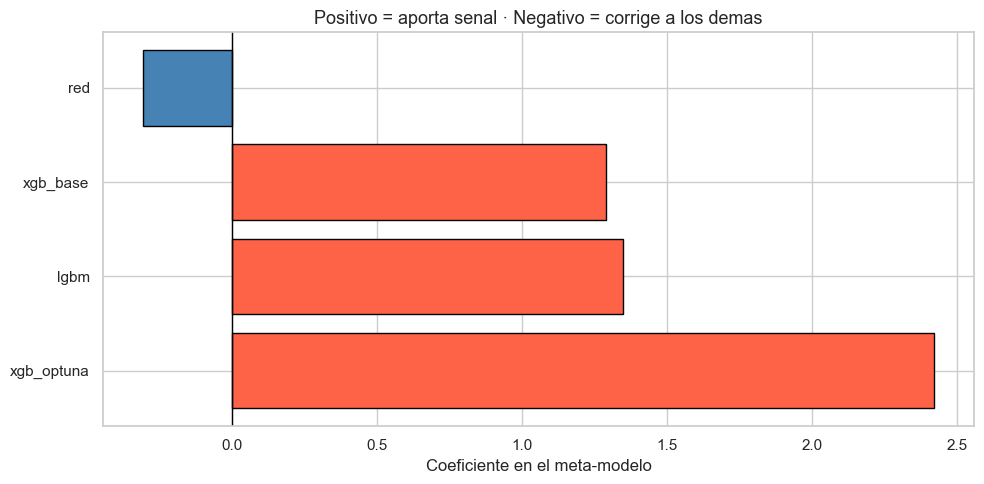


Con coeficiente negativo: red
  No predicen el target: corrigen un sesgo compartido por el resto.
  Un promedio de pesos no negativos no puede representar esto.


In [5]:
tabla = pd.DataFrame({
    "auc_solo":    [roc_auc_score(y, oof[k]) for k in nombres],
    "coeficiente": coefs.values,
}, index=nombres).sort_values("coeficiente", ascending=False)
print(tabla.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colores = ["tomato" if c > 0 else "steelblue" for c in tabla["coeficiente"]]
ax.barh(tabla.index, tabla["coeficiente"], color=colores, edgecolor="black")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Coeficiente en el meta-modelo")
ax.set_title("Positivo = aporta senal · Negativo = corrige a los demas", fontsize=13)
plt.tight_layout()
plt.show()

neg = tabla[tabla["coeficiente"] < 0]
if len(neg):
    print(f"\nCon coeficiente negativo: {', '.join(neg.index)}")
    print("  No predicen el target: corrigen un sesgo compartido por el resto.")
    print("  Un promedio de pesos no negativos no puede representar esto.")

## 5. Ablación: Qué Aporta Cada Miembro

Se quita un miembro por vez y se vuelve a ajustar el stack anidado. La caída es lo que ese miembro
aportaba **por encima de lo que ya daban los demás** — que no es lo mismo que su AUC individual.

In [6]:
filas = []
for k in nombres:
    resto = [c for c in nombres if c != k]
    auc_r, _, _, _ = stack_anidado(resto)
    filas.append({"miembro": k,
                  "auc_solo": roc_auc_score(y, oof[k]),
                  "stack_sin_el": auc_r,
                  "aporte": auc_con - auc_r,
                  "coeficiente": coefs[k]})
abl = pd.DataFrame(filas).sort_values("aporte", ascending=False)
print(abl.round(6).to_string(index=False))
print("\n  Correlacion entre AUC individual y aporte al stack: "
      f"{abl['auc_solo'].corr(abl['aporte']):+.3f}")

   miembro  auc_solo  stack_sin_el   aporte  coeficiente
xgb_optuna  0.965073      0.965063 0.000215     2.420854
       red  0.940917      0.965177 0.000101    -0.308472
      lgbm  0.964219      0.965180 0.000097     1.347295
  xgb_base  0.964776      0.965251 0.000026     1.287678

  Correlacion entre AUC individual y aporte al stack: +0.090


## 6. ¿Cuánto Techo Queda?

El target es un sorteo Bernoulli sobre un campo de probabilidad suave, así que existe un **techo duro
de AUC** por ruido de etiqueta irreducible. Con un modelo bien calibrado se lo puede estimar:

$$\text{AUC}^{*} = \frac{\mathbb{E}\left[\mathbb{1}\{p_i > p_j\}\; p_i (1-p_j)\right]}{\mathbb{E}[p]\,\mathbb{E}[1-p]}$$

Se calibra el stack out-of-fold con regresión isotónica, se verifica la tabla de confiabilidad, y
recién ahí se evalúa la fórmula. **Es una cota sobre la señal alcanzable desde la representación
actual**, no una ley del universo: si aparecieran features nuevas, el techo se mueve.

In [7]:
p = np.zeros(NTR)
for itr, iva in FOLDS:
    iso = IsotonicRegression(out_of_bounds="clip", y_min=1e-6, y_max=1 - 1e-6)
    p[iva] = iso.fit(oof_meta[itr], y[itr]).predict(oof_meta[iva])
p = np.clip(p, 1e-6, 1 - 1e-6)

conf = (pd.DataFrame({"b": pd.qcut(p, 10, labels=False, duplicates="drop"), "p": p, "y": y})
          .groupby("b").agg(n=("y", "size"), predicho=("p", "mean"), observado=("y", "mean")))
print("Tabla de confiabilidad (deciles):")
print(conf.to_string(float_format="%.4f"))
print(f"\n  max |predicho - observado| = {(conf.predicho - conf.observado).abs().max():.4f}")


def auc_bayes(p):
    p = np.sort(np.asarray(p, np.float64)); n = len(p); comp = 1.0 - p
    cum = np.concatenate([[0.0], np.cumsum(comp)[:-1]])
    return (float(np.dot(p, cum)) / (n * n)) / float(p.mean() * comp.mean())


techo = auc_bayes(p)
print(f"\n{'='*60}")
print(f"  AUC de Bayes estimado   {techo:.6f}")
print(f"  Nuestro stack (OOF)     {auc_con:.6f}")
print(f"  Recorrido restante      {techo - auc_con:+.6f}")
print(f"{'='*60}")
for lo, hi in [(0.05, 0.95), (0.4, 0.6)]:
    print(f"  Filas con probabilidad real entre {lo} y {hi}: {((p > lo) & (p < hi)).mean():.1%}")
print("\n  Esas son las filas donde la etiqueta es genuinamente azarosa dadas las features:")
print("  ningun modelo las puede ordenar bien, y son las que fijan el techo.")

Tabla de confiabilidad (deciles):
        n  predicho  observado
b                             
0   69270    0.0189     0.0191
1   69218    0.1238     0.1238
2   69482    0.3866     0.3874
3   69151    0.6982     0.6979
4   69139    0.8995     0.8992
5   68587    0.9772     0.9769
6   73026    0.9967     0.9966
7   67485    0.9994     0.9993
8  136011    1.0000     1.0000

  max |predicho - observado| = 0.0008

  AUC de Bayes estimado   0.965343
  Nuestro stack (OOF)     0.965278
  Recorrido restante      +0.000066
  Filas con probabilidad real entre 0.05 y 0.95: 39.5%
  Filas con probabilidad real entre 0.4 y 0.6: 6.2%

  Esas son las filas donde la etiqueta es genuinamente azarosa dadas las features:
  ningun modelo las puede ordenar bien, y son las que fijan el techo.


## 7. Predicción sobre Test y Submission

In [8]:
sc_full, m_full = modelo_full
pred_test = R(m_full.decision_function(sc_full.transform(Gt)))   # a rangos: AUC solo mira el orden

submission = pd.DataFrame({"id": test["id"], "addicted_label": pred_test})
submission.to_csv("../submissions/9_stack_submission.csv", index=False)
np.save("../models/9_stack_oof.npy",  oof_meta)
np.save("../models/9_stack_test.npy", pred_test)

sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "ids no alineados"
assert submission["addicted_label"].between(0, 1).all(), "valores fuera de [0, 1]"
assert submission["addicted_label"].notna().all(), "hay nulos"

print(f"Submission escrita: ../submissions/9_stack_submission.csv ({len(submission):,} filas)")
print("  Chequeos OK.")
print("\n  OJO: son rangos normalizados, no probabilidades calibradas. Para AUC da igual,")
print("  pero no se leen como P(y=1). El inventario de 8_envio_final.ipynb lo levanta solo.")

Submission escrita: ../submissions/9_stack_submission.csv (296,302 filas)
  Chequeos OK.

  OJO: son rangos normalizados, no probabilidades calibradas. Para AUC da igual,
  pero no se leen como P(y=1). El inventario de 8_envio_final.ipynb lo levanta solo.


## 8. Conclusiones

### El veredicto del notebook 5 era del método, no de la red

La red entra al meta-modelo con coeficiente **−0,3085** y aporta **+0,000101** al AUC anidado. No
predice el target: **corrige** un sesgo que comparten los tres modelos de árboles. Un promedio de
pesos no negativos no tiene forma de expresar eso, y por eso la búsqueda del notebook 5 le asignó
cero. La conclusión de aquel notebook —"la diversidad es necesaria pero no suficiente"— describía una
limitación de la combinación convexa, no una propiedad de la red.

Y a diferencia de la ganancia del notebook 6, este +0,000101 está medido con **validación anidada**:
ningún coeficiente vio la fila que califica, así que no arrastra el sesgo de selección que
diagnosticamos en el notebook 7.

### La fuerza individual no predice el aporte

| miembro | AUC solo | aporte al stack | coeficiente |
|---|---|---|---|
| xgb_optuna | 0,9651 | +0,000215 | +2,42 |
| **red** | **0,9409** | **+0,000101** | **−0,31** |
| lgbm | 0,9642 | +0,000097 | +1,35 |
| xgb_base | 0,9648 | +0,000026 | +1,29 |

La correlación entre AUC individual y aporte al stack es de **+0,09**: prácticamente nula. La red es
el miembro más débil por 0,024 de AUC y aun así aporta **más que LightGBM y cuatro veces más que el
XGBoost base**, que son mucho más fuertes que ella. Lo que un miembro suma al conjunto depende de en
qué se equivoca, no de cuánto acierta.

### Sobre el techo de Bayes: no repetir el error del notebook 6

La estimación da **0,965343**, apenas **+0,000066** por encima de nuestro stack. Sería tentador
concluir "llegamos al límite del problema" — y sería exactamente el error que cometimos en el
notebook 6 al declarar una meseta.

**La fórmula se evalúa sobre nuestras propias probabilidades calibradas**, así que mide la
**resolución** de nuestro modelo, no la del problema. Nuestra tabla de confiabilidad es muy buena
(error máximo de 0,0008 entre predicho y observado), pero **calibración y resolución son cosas
distintas**: un modelo puede estar perfectamente calibrado y ser poco filoso — predecir 0,71 para todo
el mundo está calibrado y no sirve para nada. Un modelo más fuerte produce un campo de probabilidad
más disperso, y con él un techo estimado más alto.

La lectura correcta: **estamos a 7e-5 de agotar lo que soporta nuestra representación actual**, que no
es lo mismo que estar a 7e-5 del límite del problema. Sirve para dejar de tunear estos modelos; no
para dejar de buscar.

### El ruido de etiqueta que sí es irreducible

**39,5 % de las filas** tienen probabilidad real entre 0,05 y 0,95, y **6,2 %** entre 0,4 y 0,6. En
esas últimas la etiqueta es esencialmente un sorteo dadas las features: ningún modelo las puede
ordenar. Eso es lo que fija cualquier techo, y explica por qué todo el episodio se movió en el cuarto
decimal.